# Movement To Imagery Transfer Across Models With All Channels

This notebook repeats the movement-to-imagery transfer comparison across multiple models, but now uses all EEG channels instead of the reduced `sensorimotor_17` subset.

Fixed configuration:

- channels: all available EEG channels
- band-pass: `8 to 30 Hz`
- crop window: `0.5 to 2.5 s`
- sampling rate: `160 Hz`

Compared models:

- `EEGNet`
- `ShallowConvNet`
- `DeepConvNet`

For each model, the notebook compares:

- imagery-only training
- movement-to-imagery zero-shot transfer
- movement pretrain plus imagery fine-tuning


In [1]:
import random
import time
import warnings
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from braindecode.models import Deep4Net, EEGNet, ShallowFBCSPNet
from mne import Epochs, pick_types
from mne.channels import make_standard_montage
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, TensorDataset


warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 7
DATA_ROOT = Path("/NAS/aniruddham/mne/data")
MOVEMENT_RUNS = [3, 7, 11]
IMAGERY_RUNS = [4, 8, 12]
RESAMPLE_SFREQ = 160.0
FILTER_BAND = (8.0, 30.0)
EPOCH_WINDOW = (0.0, 4.0)
CROP_WINDOW = (0.5, 2.5)
TEST_SIZE = 0.2
VAL_SIZE = 0.2
MAX_SUBJECTS = None
BATCH_SIZE = 64
PRETRAIN_EPOCHS = 12
FINETUNE_EPOCHS = 8
BASELINE_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 3
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MODEL_NAMES = ["EEGNet", "ShallowConvNet", "DeepConvNet"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MONTAGE = make_standard_montage("standard_1005")

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

print(f"Using device: {DEVICE}")


Using device: cuda


In [2]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def infer_available_subjects(data_root: Path = DATA_ROOT) -> list[int]:
    return sorted(
        int(path.name[1:])
        for path in data_root.glob("S[0-9][0-9][0-9]")
        if path.is_dir()
    )


def local_run_paths(
    subject: int, runs: list[int], data_root: Path = DATA_ROOT
) -> list[Path]:
    subject_name = f"S{subject:03d}"
    return [data_root / subject_name / f"{subject_name}R{run:02d}.edf" for run in runs]


def load_subject_raw(subject: int, runs: list[int]) -> mne.io.BaseRaw:
    paths = local_run_paths(subject, runs)
    raw = concatenate_raws(
        [read_raw_edf(path, preload=True, verbose="ERROR") for path in paths]
    )
    eegbci.standardize(raw)
    raw.pick("eeg")
    raw.set_montage(MONTAGE, match_case=False, on_missing="warn")
    raw.annotations.rename({"T1": "left_hand", "T2": "right_hand"})
    raw.set_eeg_reference("average", projection=False, verbose="ERROR")
    raw.resample(RESAMPLE_SFREQ, verbose="ERROR")
    raw.filter(
        *FILTER_BAND, fir_design="firwin", skip_by_annotation="edge", verbose="ERROR"
    )
    return raw


def epoch_subject(raw: mne.io.BaseRaw) -> tuple[np.ndarray, np.ndarray, Epochs]:
    events, event_map = mne.events_from_annotations(raw, verbose="ERROR")
    epochs = Epochs(
        raw,
        events,
        event_id={
            "left_hand": event_map["left_hand"],
            "right_hand": event_map["right_hand"],
        },
        tmin=EPOCH_WINDOW[0],
        tmax=EPOCH_WINDOW[1],
        proj=False,
        picks=pick_types(
            raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads"
        ),
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose="ERROR",
    ).crop(*CROP_WINDOW)
    if len(epochs.times) % 2 != 0:
        epochs.crop(tmin=epochs.tmin, tmax=epochs.times[-2])
    X = epochs.get_data(copy=False).astype(np.float32)
    y = (epochs.events[:, -1] == event_map["right_hand"]).astype(np.int64)
    return X, y, epochs


def build_dataset(runs: list[int]) -> dict:
    subjects = infer_available_subjects()
    if MAX_SUBJECTS is not None:
        subjects = subjects[:MAX_SUBJECTS]

    X_parts = []
    y_parts = []
    groups = []
    ch_names = None
    chs_info = None

    for subject in subjects:
        raw = load_subject_raw(subject, runs)
        X, y, epochs = epoch_subject(raw)
        if ch_names is None:
            ch_names = epochs.ch_names
            chs_info = deepcopy(epochs.info["chs"])
        X_mean = X.mean(axis=2, keepdims=True)
        X_std = X.std(axis=2, keepdims=True) + 1e-6
        X = (X - X_mean) / X_std
        X_parts.append(X)
        y_parts.append(y)
        groups.append(np.full(len(y), subject))

    return {
        "X": np.concatenate(X_parts, axis=0),
        "y": np.concatenate(y_parts, axis=0),
        "groups": np.concatenate(groups, axis=0),
        "channel_names": ch_names,
        "chs_info": chs_info,
        "sfreq": RESAMPLE_SFREQ,
    }


def make_group_split(groups: np.ndarray, seed: int = SEED) -> dict:
    index = np.arange(len(groups))
    outer = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
    train_val_idx, test_idx = next(outer.split(index, groups=groups))
    inner = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=seed + 1)
    inner_train_rel, inner_val_rel = next(
        inner.split(np.arange(len(train_val_idx)), groups=groups[train_val_idx])
    )
    return {
        "train": train_val_idx[inner_train_rel],
        "val": train_val_idx[inner_val_rel],
        "test": test_idx,
    }


set_seed()
movement_ds = build_dataset(MOVEMENT_RUNS)
imagery_ds = build_dataset(IMAGERY_RUNS)
imagery_split = make_group_split(imagery_ds["groups"])
movement_split = make_group_split(movement_ds["groups"])

display(
    pd.DataFrame(
        {
            "dataset": ["movement", "imagery"],
            "epochs": [len(movement_ds["y"]), len(imagery_ds["y"])],
            "left_trials": [
                int((movement_ds["y"] == 0).sum()),
                int((imagery_ds["y"] == 0).sum()),
            ],
            "right_trials": [
                int((movement_ds["y"] == 1).sum()),
                int((imagery_ds["y"] == 1).sum()),
            ],
            "channels": [
                len(movement_ds["channel_names"]),
                len(imagery_ds["channel_names"]),
            ],
            "samples_per_epoch": [
                movement_ds["X"].shape[-1],
                imagery_ds["X"].shape[-1],
            ],
        }
    )
)


,dataset,epochs,left_trials,right_trials,channels,samples_per_epoch
0,movement,4897,2452,2445,64,320
1,imagery,4898,2470,2428,64,320


In [3]:
def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool) -> DataLoader:
    return DataLoader(
        TensorDataset(torch.from_numpy(X), torch.from_numpy(y)),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        drop_last=False,
    )


def unpack_logits(logits):
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    while logits.ndim > 2 and logits.shape[-1] == 1:
        logits = logits.squeeze(-1)
    if logits.ndim > 2:
        logits = logits.mean(dim=tuple(range(2, logits.ndim)))
    return logits


@torch.no_grad()
def collect_predictions(
    model: nn.Module, loader: DataLoader
) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    pred_labels = []
    pred_probs = []
    for batch_X, _ in loader:
        batch_X = batch_X.to(DEVICE)
        logits = unpack_logits(model(batch_X))
        probs = torch.softmax(logits, dim=1)[:, 1]
        pred_probs.append(probs.cpu().numpy())
        pred_labels.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(pred_labels), np.concatenate(pred_probs)


def evaluate_loss_accuracy(
    model: nn.Module, loader: DataLoader, criterion: nn.Module
) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    for batch_X, batch_y in loader:
        batch_X = batch_X.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        logits = unpack_logits(model(batch_X))
        loss = criterion(logits, batch_y)
        total_loss += loss.item() * len(batch_y)
        total_correct += (logits.argmax(dim=1) == batch_y).sum().item()
        total_count += len(batch_y)
    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


def build_model(model_name: str) -> nn.Module:
    common = dict(
        n_chans=imagery_ds["X"].shape[1],
        n_times=imagery_ds["X"].shape[2],
        n_outputs=2,
        sfreq=imagery_ds["sfreq"],
        chs_info=imagery_ds["chs_info"],
    )
    if model_name == "EEGNet":
        return EEGNet(**common).to(DEVICE)
    if model_name == "ShallowConvNet":
        return ShallowFBCSPNet(**common).to(DEVICE)
    if model_name == "DeepConvNet":
        return Deep4Net(**common).to(DEVICE)
    raise KeyError(model_name)


def train_phase(model, train_loader, val_loader, y_val, max_epochs, lr=LEARNING_RATE):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    best_state = None
    best_val_bal = -np.inf
    best_epoch = 0
    patience_counter = 0
    start = time.perf_counter()
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = unpack_logits(model(batch_X))
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate_loss_accuracy(model, train_loader, criterion)
        val_loss, val_acc = evaluate_loss_accuracy(model, val_loader, criterion)
        val_pred, _ = collect_predictions(model, val_loader)
        val_bal = balanced_accuracy_score(y_val, val_pred)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_accuracy": train_acc,
                "val_accuracy": val_acc,
                "val_balanced_accuracy": val_bal,
            }
        )

        if val_bal > best_val_bal + 1e-4:
            best_val_bal = val_bal
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_epoch, time.perf_counter() - start


def summarize_result(model, X_test, y_test, label, groups_test):
    test_loader = make_loader(X_test, y_test, shuffle=False)
    pred, prob = collect_predictions(model, test_loader)
    return {
        "experiment": label,
        "test_accuracy": float((pred == y_test).mean()),
        "test_balanced_accuracy": float(balanced_accuracy_score(y_test, pred)),
        "test_auc": float(roc_auc_score(y_test, prob)),
        "pred": pred,
        "prob": prob,
        "groups": groups_test,
    }


In [4]:
X_i_train, y_i_train = (
    imagery_ds["X"][imagery_split["train"]],
    imagery_ds["y"][imagery_split["train"]],
)
X_i_val, y_i_val = (
    imagery_ds["X"][imagery_split["val"]],
    imagery_ds["y"][imagery_split["val"]],
)
X_i_test, y_i_test = (
    imagery_ds["X"][imagery_split["test"]],
    imagery_ds["y"][imagery_split["test"]],
)
g_i_test = imagery_ds["groups"][imagery_split["test"]]

X_m_train, y_m_train = (
    movement_ds["X"][movement_split["train"]],
    movement_ds["y"][movement_split["train"]],
)
X_m_val, y_m_val = (
    movement_ds["X"][movement_split["val"]],
    movement_ds["y"][movement_split["val"]],
)

results = []
history_rows = []

for model_name in MODEL_NAMES:
    print(f"Running transfer comparison for {model_name}...")

    imagery_model = build_model(model_name)
    imagery_model, imagery_hist, imagery_best_epoch, imagery_time = train_phase(
        imagery_model,
        make_loader(X_i_train, y_i_train, shuffle=True),
        make_loader(X_i_val, y_i_val, shuffle=False),
        y_i_val,
        BASELINE_EPOCHS,
    )
    imagery_result = summarize_result(
        imagery_model, X_i_test, y_i_test, "imagery_only", g_i_test
    )
    imagery_result.update(
        {
            "model": model_name,
            "best_epoch": imagery_best_epoch,
            "training_time_s": imagery_time,
        }
    )
    imagery_hist["model"] = model_name
    imagery_hist["experiment"] = "imagery_only"
    history_rows.append(imagery_hist)
    results.append(
        {k: v for k, v in imagery_result.items() if k not in {"pred", "prob", "groups"}}
    )

    transfer_model = build_model(model_name)
    transfer_model, transfer_hist, transfer_best_epoch, transfer_time = train_phase(
        transfer_model,
        make_loader(X_m_train, y_m_train, shuffle=True),
        make_loader(X_m_val, y_m_val, shuffle=False),
        y_m_val,
        PRETRAIN_EPOCHS,
    )
    transfer_result = summarize_result(
        transfer_model, X_i_test, y_i_test, "movement_to_imagery", g_i_test
    )
    transfer_result.update(
        {
            "model": model_name,
            "best_epoch": transfer_best_epoch,
            "training_time_s": transfer_time,
        }
    )
    transfer_hist["model"] = model_name
    transfer_hist["experiment"] = "movement_to_imagery"
    history_rows.append(transfer_hist)
    results.append(
        {
            k: v
            for k, v in transfer_result.items()
            if k not in {"pred", "prob", "groups"}
        }
    )

    finetune_model = build_model(model_name)
    finetune_model, pre_hist, pre_best_epoch, pre_time = train_phase(
        finetune_model,
        make_loader(X_m_train, y_m_train, shuffle=True),
        make_loader(X_m_val, y_m_val, shuffle=False),
        y_m_val,
        PRETRAIN_EPOCHS,
    )
    finetune_model, ft_hist, ft_best_epoch, ft_time = train_phase(
        finetune_model,
        make_loader(X_i_train, y_i_train, shuffle=True),
        make_loader(X_i_val, y_i_val, shuffle=False),
        y_i_val,
        FINETUNE_EPOCHS,
        lr=LEARNING_RATE * 0.5,
    )
    finetune_result = summarize_result(
        finetune_model,
        X_i_test,
        y_i_test,
        "movement_pretrain_plus_imagery_finetune",
        g_i_test,
    )
    finetune_result.update(
        {
            "model": model_name,
            "best_epoch": ft_best_epoch,
            "training_time_s": pre_time + ft_time,
        }
    )
    ft_hist["model"] = model_name
    ft_hist["experiment"] = "movement_pretrain_plus_imagery_finetune"
    history_rows.append(ft_hist)
    results.append(
        {
            k: v
            for k, v in finetune_result.items()
            if k not in {"pred", "prob", "groups"}
        }
    )

results_df = pd.DataFrame(results).sort_values(
    ["model", "test_balanced_accuracy"], ascending=[True, False]
)
history_df = pd.concat(history_rows, ignore_index=True)
display(results_df)


Running transfer comparison for EEGNet...
Running transfer comparison for ShallowConvNet...
Running transfer comparison for DeepConvNet...


,experiment,test_accuracy,test_balanced_accuracy,test_auc,model,best_epoch,training_time_s
6,imagery_only,0.529828,0.527262,0.554701,DeepConvNet,11,9.042060
7,movement_to_imagery,0.513650,0.515243,0.506466,DeepConvNet,1,2.809139
8,movement_pretrain_plus_imagery_finetune,0.516684,0.512372,0.543738,DeepConvNet,1,7.784252
0,imagery_only,0.579373,0.577904,0.631276,EEGNet,10,10.188906
2,movement_pretrain_plus_imagery_finetune,0.576340,0.576096,0.605767,EEGNet,6,15.730056
1,movement_to_imagery,0.553084,0.553231,0.598172,EEGNet,11,9.919712
3,imagery_only,0.581395,0.581276,0.615002,ShallowConvNet,5,5.500142
5,movement_pretrain_plus_imagery_finetune,0.576340,0.576816,0.616139,ShallowConvNet,7,10.848215
4,movement_to_imagery,0.565217,0.564466,0.590237,ShallowConvNet,10,7.895341


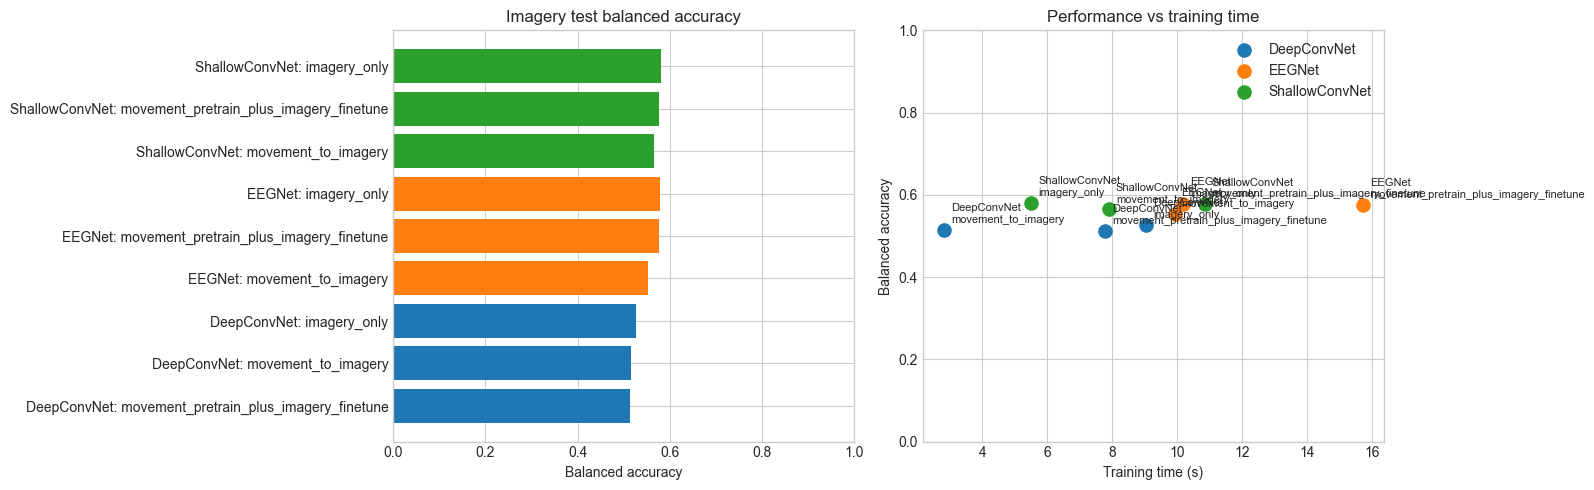

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for model_name, model_df in results_df.groupby("model"):
    ordered = model_df.sort_values("test_balanced_accuracy", ascending=True)
    axes[0].barh(
        [f"{model_name}: {name}" for name in ordered["experiment"]],
        ordered["test_balanced_accuracy"],
        label=model_name,
    )
axes[0].set_title("Imagery test balanced accuracy")
axes[0].set_xlabel("Balanced accuracy")
axes[0].set_xlim(0.0, 1.0)

for model_name, model_df in results_df.groupby("model"):
    axes[1].scatter(
        model_df["training_time_s"],
        model_df["test_balanced_accuracy"],
        s=90,
        label=model_name,
    )
    for _, row in model_df.iterrows():
        axes[1].annotate(
            f"{model_name}\n{row['experiment']}",
            (row["training_time_s"], row["test_balanced_accuracy"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )
axes[1].set_title("Performance vs training time")
axes[1].set_xlabel("Training time (s)")
axes[1].set_ylabel("Balanced accuracy")
axes[1].set_ylim(0.0, 1.0)
axes[1].legend()

plt.tight_layout()
plt.show()


experiment,imagery_only,movement_pretrain_plus_imagery_finetune,movement_to_imagery,transfer_minus_imagery,finetune_minus_imagery
model,,,,,
EEGNet,0.577904,0.576096,0.553231,-0.024673,-0.001808
ShallowConvNet,0.581276,0.576816,0.564466,-0.016810,-0.004460
DeepConvNet,0.527262,0.512372,0.515243,-0.012018,-0.014890


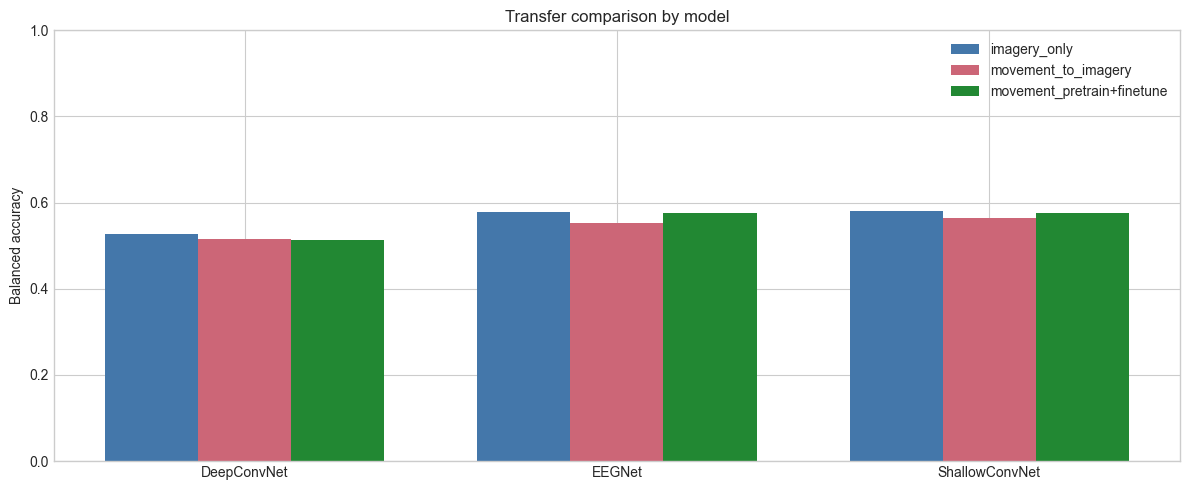

In [6]:
improvement_table = results_df.pivot(
    index="model", columns="experiment", values="test_balanced_accuracy"
)
improvement_table["transfer_minus_imagery"] = (
    improvement_table["movement_to_imagery"] - improvement_table["imagery_only"]
)
improvement_table["finetune_minus_imagery"] = (
    improvement_table["movement_pretrain_plus_imagery_finetune"]
    - improvement_table["imagery_only"]
)
display(improvement_table.sort_values("finetune_minus_imagery", ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
width = 0.25
x = np.arange(len(improvement_table.index))
ax.bar(
    x - width,
    improvement_table["imagery_only"],
    width=width,
    label="imagery_only",
    color="#4477AA",
)
ax.bar(
    x,
    improvement_table["movement_to_imagery"],
    width=width,
    label="movement_to_imagery",
    color="#CC6677",
)
ax.bar(
    x + width,
    improvement_table["movement_pretrain_plus_imagery_finetune"],
    width=width,
    label="movement_pretrain+finetune",
    color="#228833",
)
ax.set_xticks(x)
ax.set_xticklabels(improvement_table.index)
ax.set_title("Transfer comparison by model")
ax.set_ylabel("Balanced accuracy")
ax.set_ylim(0.0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()
